**Motion Tracking**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib # For Model Persistence
from scipy import signal
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
# configuration
CONFIG = {
    'window_seconds': 2.0,
    'overlap': 0.5,
    'filter_cutoff': 20.0,
    'files': {
        'left_hand.csv': 'left_hand',
        'left_pocket.csv': 'left_pocket',
        'right_hand.csv': 'right_hand',
        'right_pocket.csv': 'right_pocket'
    }
}

In [3]:
# data loading
data_frames = []
for filename, label in CONFIG['files'].items():
    try:
        df = pd.read_csv(filename)
        df['class'] = label
        data_frames.append(df)
        print(f"Loaded: {filename}")
    except FileNotFoundError:
        print(f"ERROR: {filename} not found.")
raw_data = pd.concat(data_frames, ignore_index=True)

Loaded: left_hand.csv
Loaded: left_pocket.csv
Loaded: right_hand.csv
Loaded: right_pocket.csv


In [4]:
# sampling rate detection
time_diffs = raw_data['Time (s)'].diff().dropna()
fs = 1 / data_frames[0]['Time (s)'].diff().median()
print(f"\n[Step 4] Sampling Rate: {fs:.2f} Hz")


[Step 4] Sampling Rate: 99.34 Hz


In [5]:
# filter design
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, data)

In [6]:
# filter application
clean_axes = []
raw_axes = ['Acceleration x (m/s^2)', 'Acceleration y (m/s^2)', 'Acceleration z (m/s^2)']
for col in raw_axes:
    new_col = f'filt_{col}'
    clean_axes.append(new_col)
    raw_data[new_col] = butter_lowpass_filter(raw_data[col], CONFIG['filter_cutoff'], fs)
print("20Hz Low-Pass Filter Applied.")

20Hz Low-Pass Filter Applied.


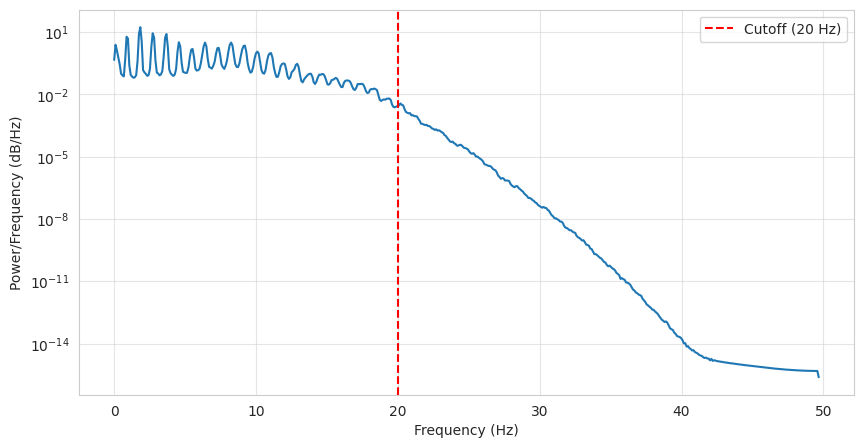

In [7]:
# PSD analysis (frequency domain)
f, Pxx_den = signal.welch(raw_data['filt_Acceleration y (m/s^2)'].values, fs, nperseg=1024)
plt.figure(figsize=(10, 5))
plt.semilogy(f, Pxx_den)

# Adding the labels
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')

plt.axvline(x=20, color='r', linestyle='--', label='Cutoff (20 Hz)')
plt.grid(True, which="both", ls="-", alpha=0.5) # Added grid for better readability
plt.legend()

# Save and Show
plt.savefig('psd_plot.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

Corrected Sampling Rate: 99.34 Hz


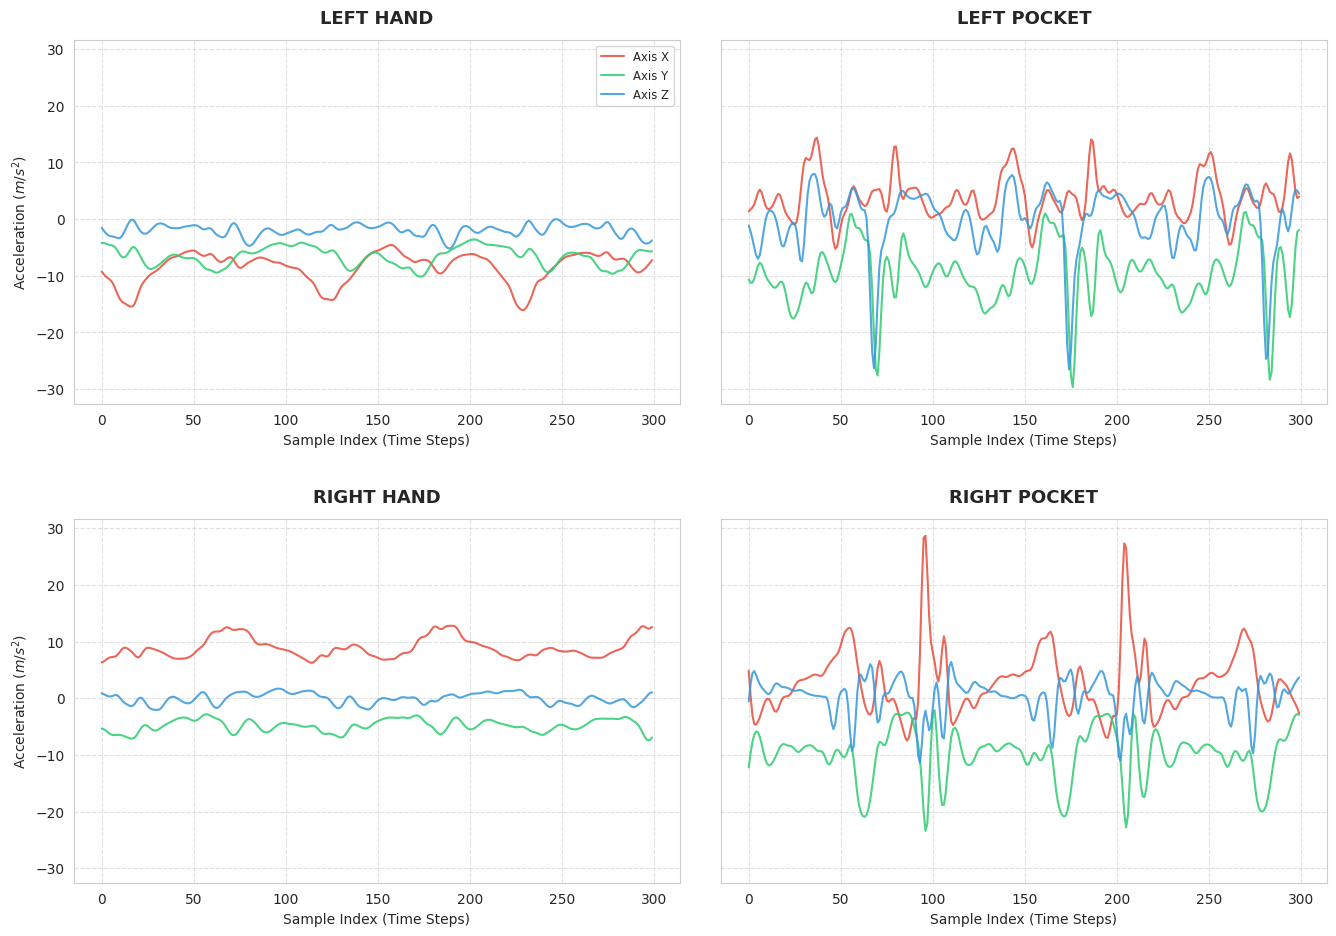

Window Size: 198 samples (~2 seconds)


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import signal

# --- 1. CONFIGURATION & DATA LOADING ---
CONFIG = {
    'window_seconds': 2.0,
    'overlap': 0.5,
    'filter_cutoff': 20.0,
    'files': {
        'left_hand.csv': 'left_hand',
        'left_pocket.csv': 'left_pocket',
        'right_hand.csv': 'right_hand',
        'right_pocket.csv': 'right_pocket'
    }
}

# Helper function for filtering
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, data)

data_frames = []
for filename, label in CONFIG['files'].items():
    try:
        df = pd.read_csv(filename)
        df['class'] = label
        data_frames.append(df)
    except FileNotFoundError:
        print(f"ERROR: {filename} not found.")

# --- 2. THE CRITICAL FIX: CALCULATE FS CORRECTLY ---
# We use the median time difference from the first file only.
# This avoids the "negative time jumps" between concatenated files.
fs = 1 / data_frames[0]['Time (s)'].diff().median()
print(f"Corrected Sampling Rate: {fs:.2f} Hz")

# Now concatenate for filtering and plotting
raw_data = pd.concat(data_frames, ignore_index=True)

# Apply filter using the CORRECT fs
clean_axes = []
raw_axes = ['Acceleration x (m/s^2)', 'Acceleration y (m/s^2)', 'Acceleration z (m/s^2)']
for col in raw_axes:
    new_col = f'filt_{col}'
    clean_axes.append(new_col)
    raw_data[new_col] = butter_lowpass_filter(raw_data[col], CONFIG['filter_cutoff'], fs)

# --- 3. BEAUTIFUL PLOTTING ---
plt.style.use('seaborn-v0_8-muted')
fig, axes_plot = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes_plot = axes_plot.flatten()

colors = ['#E74C3C', '#2ECC71', '#3498DB']
unique_labels = raw_data['class'].unique()

for i, label in enumerate(unique_labels):
    subset = raw_data[raw_data['class'] == label]
    start = len(subset) // 2

    # 300 samples at 100Hz = 3.0 seconds of walking data
    window = subset.iloc[start : start + 300].copy()

    # Reset index so the X-axis starts at 0 for every plot
    window.reset_index(drop=True, inplace=True)

    for idx, col in enumerate(clean_axes):
        axis_name = col.split(' ')[1].upper()
        axes_plot[i].plot(window[col], label=f'Axis {axis_name}', color=colors[idx], linewidth=1.5, alpha=0.85)

    axes_plot[i].set_title(label.upper().replace('_', ' '), weight='semibold', fontsize=13, pad=12)
    axes_plot[i].grid(True, linestyle='--', alpha=0.6)
    axes_plot[i].set_xlabel('Sample Index (Time Steps)', fontsize=10)

    if i % 2 == 0:
        axes_plot[i].set_ylabel('Acceleration ($m/s^2$)', fontsize=10)

axes_plot[0].legend(loc='upper right', frameon=True, fontsize='small')
plt.tight_layout(pad=3.0)
plt.savefig('signal_signatures.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

# --- 4. VERIFY INSTANCE COUNT ---
window_samples = int(fs * CONFIG['window_seconds']) # Will be ~200 samples
print(f"Window Size: {window_samples} samples (~2 seconds)")

In [9]:
# Updated Feature Extraction Logic
all_features_list = []

# Calculate step_size based on window_samples and overlap
step_size = int(window_samples * (1 - CONFIG['overlap']))

for label in raw_data['class'].unique():
    subset = raw_data[raw_data['class'] == label]

    for i in range(0, len(subset) - window_samples, step_size):
        window = subset.iloc[i : i + window_samples]
        row = {'class': label}

        # 1. Axis Features (X, Y, Z) - 18 Features
        for axis in clean_axes:
            axis_name = axis.split(' ')[1] # Gets 'x', 'y', or 'z'
            sig = window[axis]
            row[f'mean_{axis_name}'] = sig.mean()
            row[f'std_{axis_name}'] = sig.std()
            row[f'min_{axis_name}'] = sig.min()
            row[f'max_{axis_name}'] = sig.max()
            row[f'range_{axis_name}'] = sig.max() - sig.min()
            row[f'rms_{axis_name}'] = np.sqrt(np.mean(sig**2))

        # 2. Magnitude Features (Orientation Invariant) - 3 Features
        # Uses the 'Absolute acceleration' column from your Phyphox data
        mag_sig = window['Absolute acceleration (m/s^2)']
        row['mean_mag'] = mag_sig.mean()
        row['std_mag'] = mag_sig.std()
        row['mag_energy'] = np.mean(mag_sig**2)

        # 3. Frequency Feature (Rhythm) - 1 Feature
        # We use the FFT to calculate Spectral Entropy
        yf = np.fft.fft(window['filt_Acceleration y (m/s^2)'].values)
        psd = np.abs(yf)**2
        psd_norm = psd / np.sum(psd)
        row['spectral_entropy'] = -np.sum(psd_norm * np.log2(psd_norm + 1e-9))

        all_features_list.append(row)

df_all = pd.DataFrame(all_features_list)
print(f"DataFrame df_all created with shape: {df_all.shape}")

DataFrame df_all created with shape: (1219, 23)


We use an Isolation Forest to automatically detect and remove anomalies (e.g., dropping the phone, stumbling) that could confuse the model.

In [10]:
X_clean = df_all.drop('class', axis=1)
iso = IsolationForest(contamination=0.02, random_state=42) # assume 2% outliers
yhat = iso.fit_predict(X_clean)
# keep only inliers (yhat != -1)
mask = yhat != -1
df_clean = df_all[mask]
print(f" -> Removed {len(df_all) - len(df_clean)} outliers. New count: {len(df_clean)}")

 -> Removed 25 outliers. New count: 1194


We visualize the class distribution to ensure the dataset is balanced. A balanced dataset prevents the model from being biased toward the majority class.

/tmp/ipython-input-3944043728.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


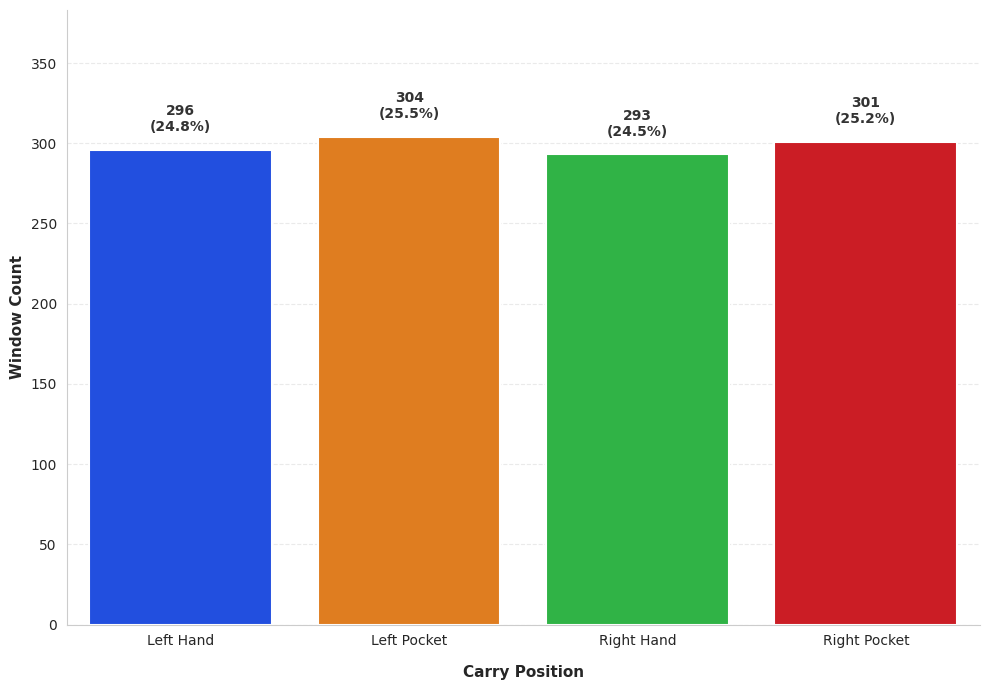

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aesthetics Setup
plt.style.use('seaborn-v0_8-muted')
plt.figure(figsize=(10, 7))

# Clean up names for display (Left Hand instead of left_hand)
df_display = df_clean.copy()
df_display['class_display'] = df_display['class'].str.replace('_', ' ').str.title()
category_order = ['Left Hand', 'Left Pocket', 'Right Hand', 'Right Pocket']

# 2. Plotting the Countplot
# Using 'bright' palette for consistency across your entire report
ax = sns.countplot(
    x='class_display',
    data=df_display,
    order=category_order,
    palette='bright',
    edgecolor='white',
    linewidth=1.5
)

# 3. Modern Annotations (Semibold and centered)
total = len(df_display)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'

    ax.annotate(f'{count}\n({percentage})',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 22), # Elevated for clarity
                textcoords='offset points',
                fontsize=10, weight='semibold', color='#333333')

# 4. Labels and Title Styling

plt.xlabel('Carry Position', fontsize=11, weight='semibold', labelpad=12)
plt.ylabel('Window Count', fontsize=11, weight='semibold')

# 5. Final Layout Adjustments
sns.despine() # Removes top and right spine for a modern look
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, ax.get_ylim()[1] * 1.2) # Extra space for top labels

plt.tight_layout()
plt.savefig('class_distribution.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

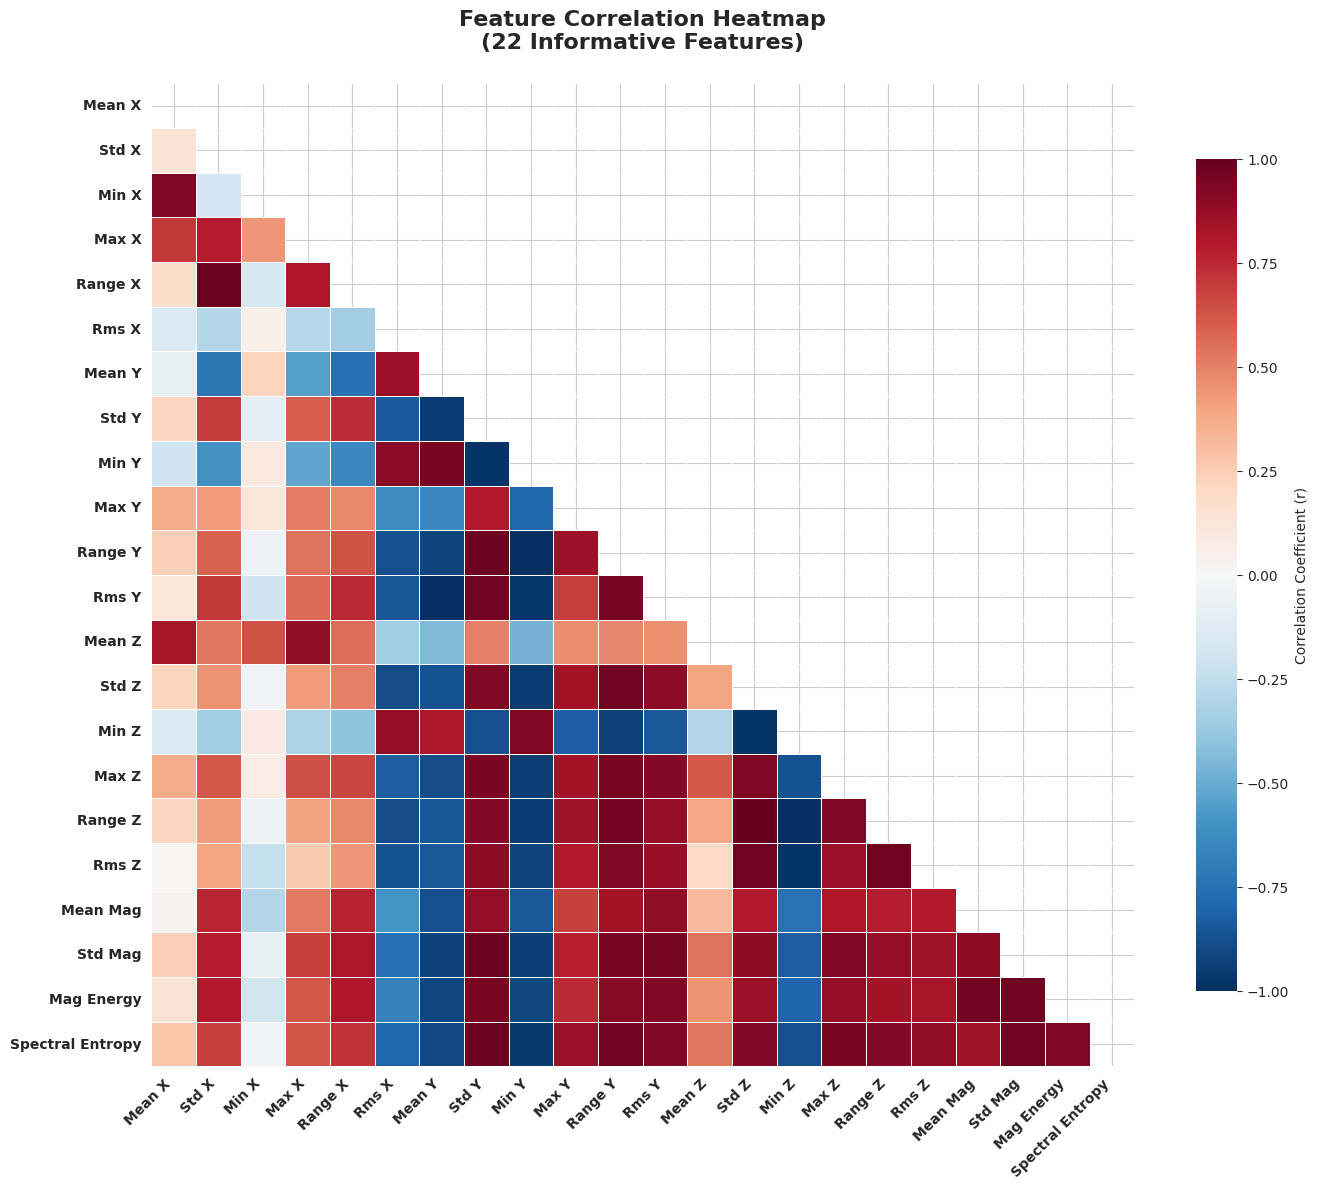

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA CLEANING FOR CORRELATION ---
# Create a copy to avoid modifying original df_clean
df_temp = df_clean.drop('class', axis=1).copy()

# Fix Spectral Entropy NaNs specifically first (common FFT artifact)
if 'spectral_entropy' in df_temp.columns:
    df_temp['spectral_entropy'] = df_temp['spectral_entropy'].fillna(0)

# Identify and drop columns that have ZERO variance (constant values)
# We calculate std and keep only those > 0.0001 to handle tiny float noise
selector = df_temp.std() > 1e-6
df_corr_ready = df_temp.loc[:, selector]

# Final fill for any other math artifacts
df_corr_ready = df_corr_ready.fillna(0)

# Compute correlation matrix
corr = df_corr_ready.corr()

# --- 2. SETUP AESTHETICS ---
plt.figure(figsize=(14, 12))
plt.style.use('seaborn-v0_8-muted')

mask = np.triu(np.ones_like(corr, dtype=bool))
clean_labels = [col.replace('_', ' ').title() for col in corr.columns]

# --- 3. PLOT HEATMAP ---
heatmap = sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    annot=False,
    linewidths=.5,
    vmin=-1, vmax=1,
    cbar_kws={"shrink": .8, "label": "Correlation Coefficient (r)"},
    square=True
)

# --- 4. FORMAT LABELS & TITLE ---
heatmap.set_xticklabels(clean_labels, rotation=45, horizontalalignment='right',
                        weight='semibold', fontsize=10)
heatmap.set_yticklabels(clean_labels, rotation=0,
                        weight='semibold', fontsize=10)

plt.title(f"Feature Correlation Heatmap\n({len(corr.columns)} Informative Features)",
          fontsize=16, weight='bold', pad=25)

plt.tight_layout()
plt.savefig('feature_correlation.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

# DIAGNOSTIC PRINT
dropped = set(df_temp.columns) - set(df_corr_ready.columns)
if dropped:
    print(f"Note: The following columns were removed because they were constant: {dropped}")

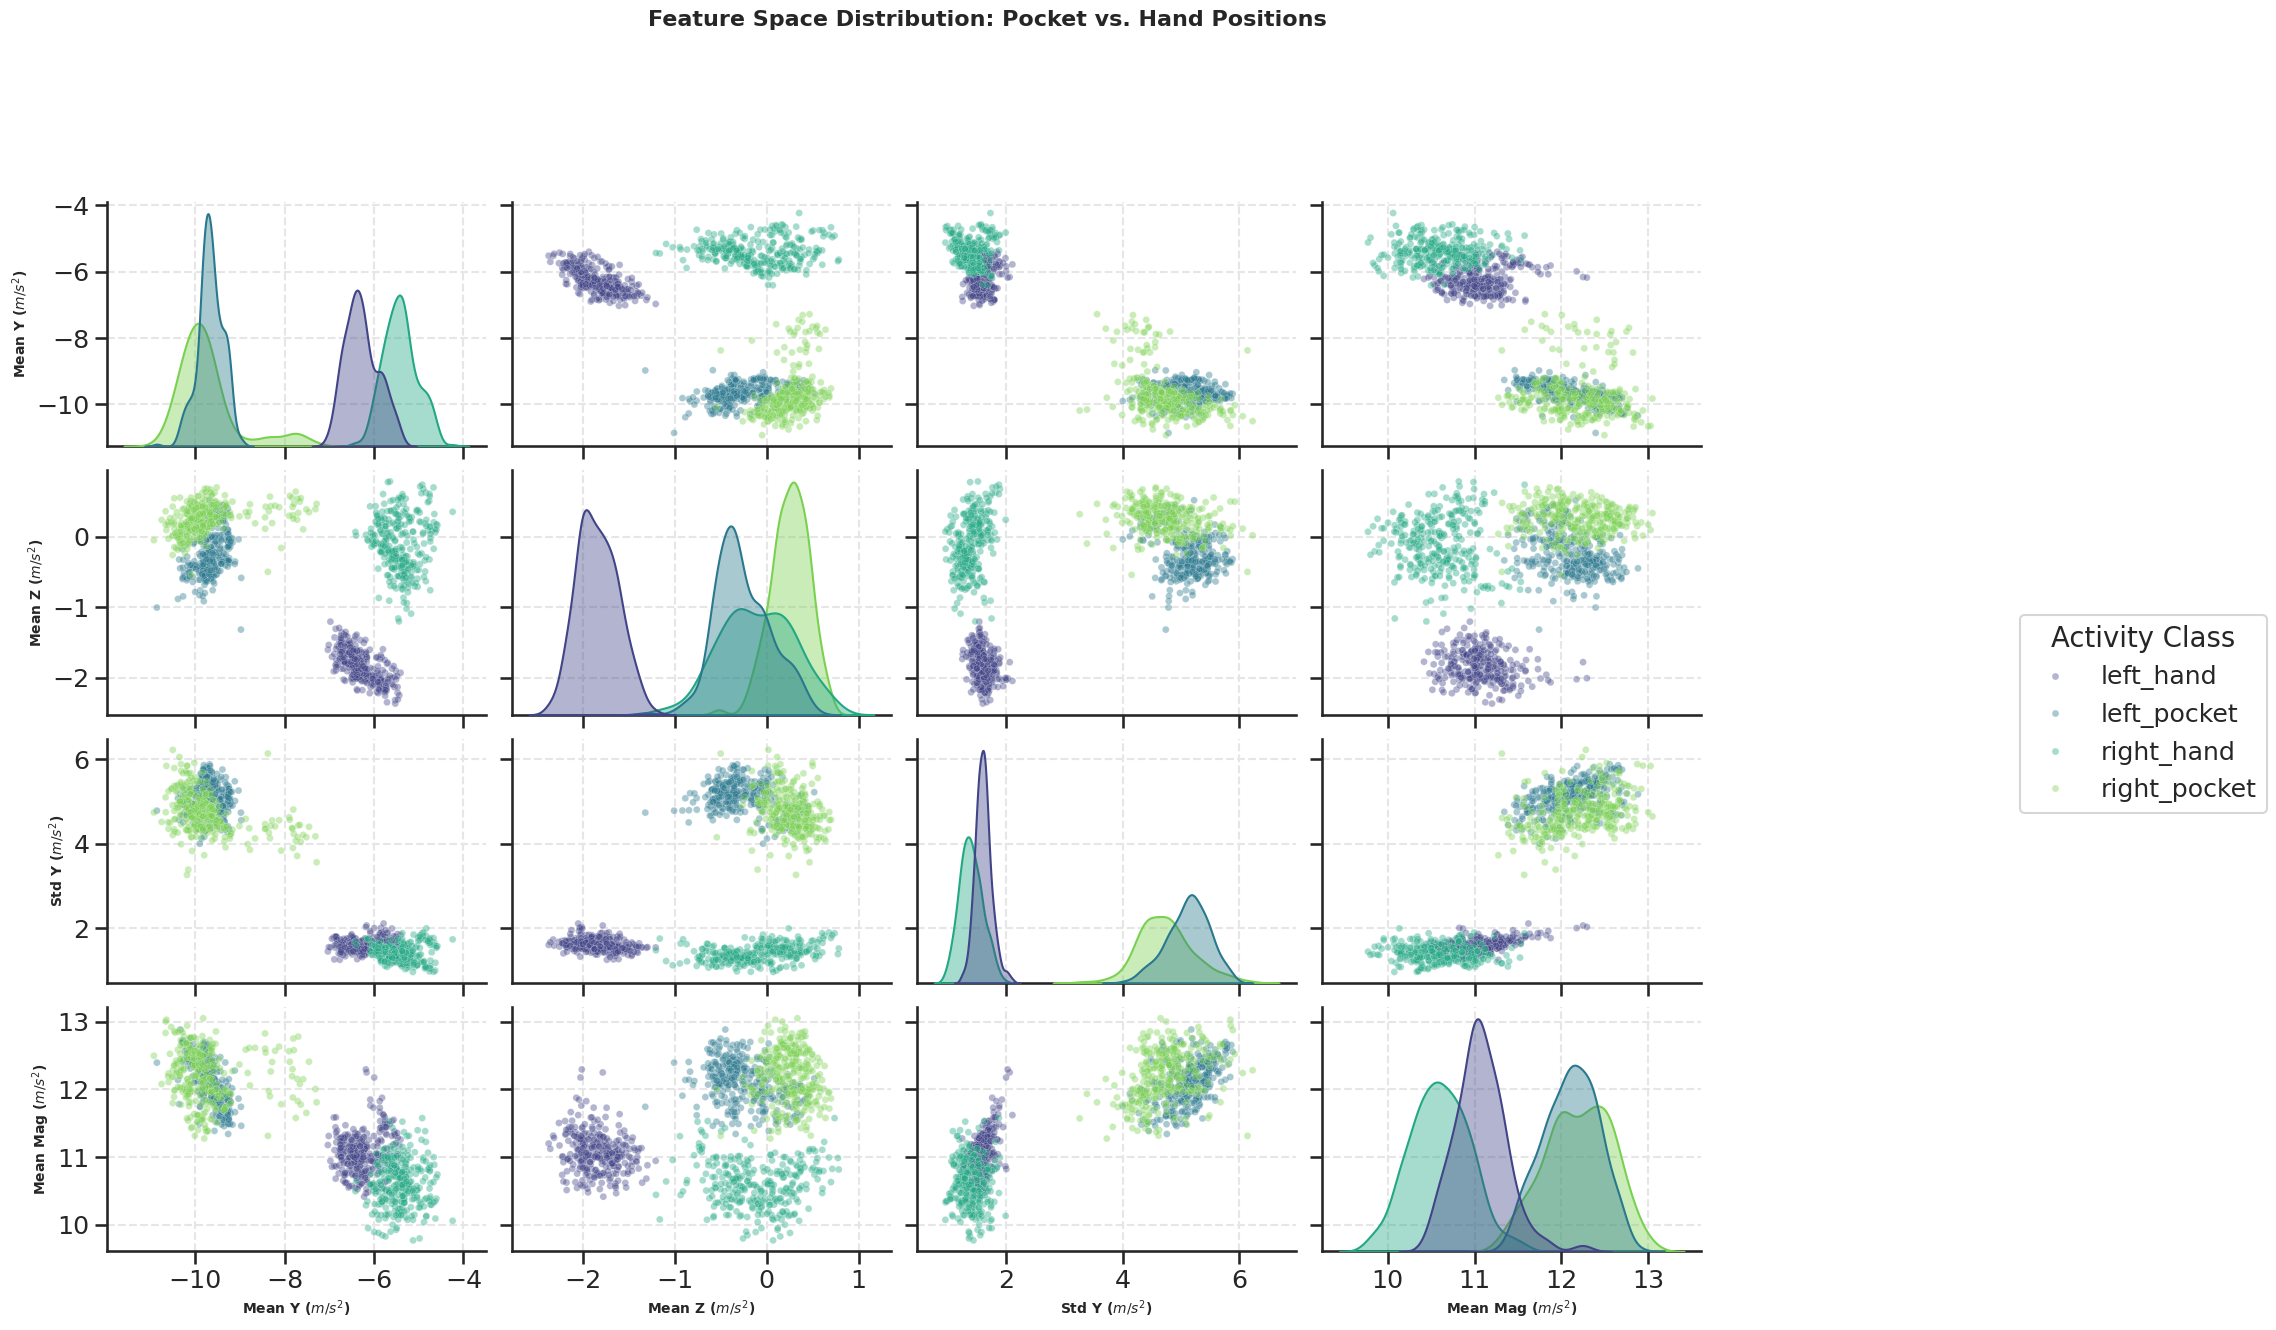

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setting a clean academic style
sns.set_style("ticks", {'axes.grid': True, 'grid.linestyle': '--', 'grid.color': '.9'})
sns.set_context("talk", font_scale=1.1)

# RECOMMENDATION: Include 'mean_mag' or 'spectral_entropy'
# to show how your NEW features contribute to class separation.
plot_vars = ['mean_y', 'mean_z', 'std_y', 'mean_mag']

# 2. INCREASE ASPECT for Landscape and HEIGHT for overall size
g = sns.pairplot(df_clean,
                 vars=plot_vars,
                 hue='class',
                 palette='viridis', # RECOMMENDATION: More professional/accessible palette
                 diag_kind='kde',
                 height=3.2,
                 aspect=1.4,
                 plot_kws={
                     'alpha': 0.4,
                     's': 25,        # RECOMMENDATION: Slightly smaller points for 1200+ samples
                     'edgecolor': 'white',
                     'linewidth': 0.3
                 },
                 diag_kws={'fill': True, 'alpha': 0.4, 'linewidth': 1.5})

# 3. Format Labels & Add Physical Context
for ax in g.axes.flatten():
    if ax:
        label = ax.get_xlabel().replace('_', ' ').title()
        # RECOMMENDATION: Add units where applicable for the report
        if 'Mean' in label or 'Std' in label:
            label += " ($m/s^2$)"
        ax.set_xlabel(label, weight='semibold', fontsize=10)
        ax.set_ylabel(ax.get_ylabel().replace('_', ' ').title() + " ($m/s^2$)",
                      weight='semibold', fontsize=10)

# 4. FIX GAP: Move legend closer
sns.move_legend(g, "center left", bbox_to_anchor=(1.0, 0.5),
                frameon=True, title="Activity Class", borderaxespad=0.5)

# 5. Add a Super Title (Optional for the Notebook, great for reports)
g.fig.suptitle("Feature Space Distribution: Pocket vs. Hand Positions",
               y=1.05, weight='bold', fontsize=16)

# Final landscape adjustment
plt.subplots_adjust(top=0.9, right=0.85)

# 6. Save as PDF for best quality in LaTeX/Reports
plt.savefig('feature_space_clusters.pdf', format='pdf', bbox_inches='tight')
plt.savefig('feature_space_clusters.eps', format='eps', bbox_inches='tight')
plt.show()

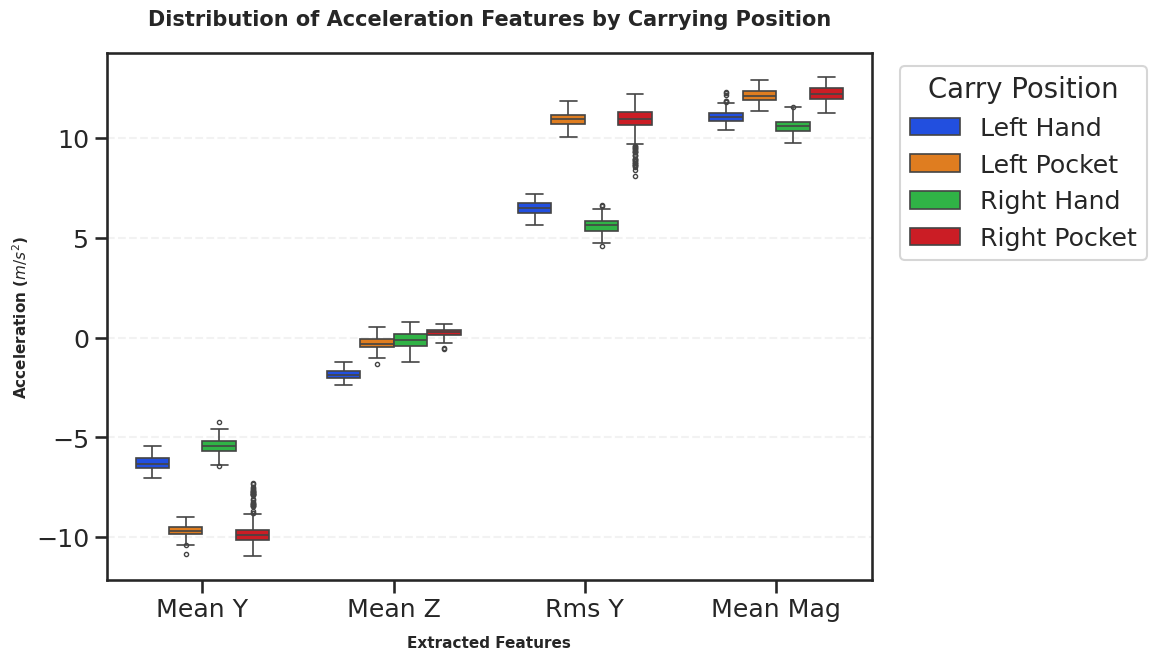

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Aesthetics
try:
    plt.style.use('seaborn-v0_8-muted')
except:
    plt.style.use('seaborn-muted')

# RECOMMENDATION: Use features that share the same unit (m/s^2)
# We swap mean_x for mean_mag to show your engineered feature!
key_features = ['mean_y', 'mean_z', 'rms_y', 'mean_mag']

# Prepare data for grouped visualization (Melt)
df_melt = df_clean.melt(id_vars='class', value_vars=key_features,
                        var_name='Feature', value_name='Acceleration (m/s²)')

# Clean labels for display
df_melt['Feature'] = df_melt['Feature'].str.replace('_', ' ').str.title()
df_melt['class'] = df_melt['class'].str.replace('_', ' ').str.title()

plt.figure(figsize=(12, 7))

# 2. Plotting Grouped Boxplot
# Using 'bright' to match your other plots
box = sns.boxplot(
    data=df_melt,
    x='Feature',
    y='Acceleration (m/s²)',
    hue='class',
    palette='bright',
    linewidth=1.2,
    fliersize=3, # Slightly smaller fliers for 1200 points
    width=0.7
)

# RECOMMENDATION: Add a descriptive title
plt.title("Distribution of Acceleration Features by Carrying Position",
          fontsize=15, weight='bold', pad=20)

plt.xlabel('Extracted Features', fontsize=11, weight='semibold', labelpad=10)
plt.ylabel('Acceleration ($m/s^2$)', fontsize=11, weight='semibold')

plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Move legend outside to the right
plt.legend(title='Carry Position', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('feature_boxplot.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

We visualize the 3D Gravity Vector. The distinct separation of clusters proves that the static orientation of the phone is unique for each class.

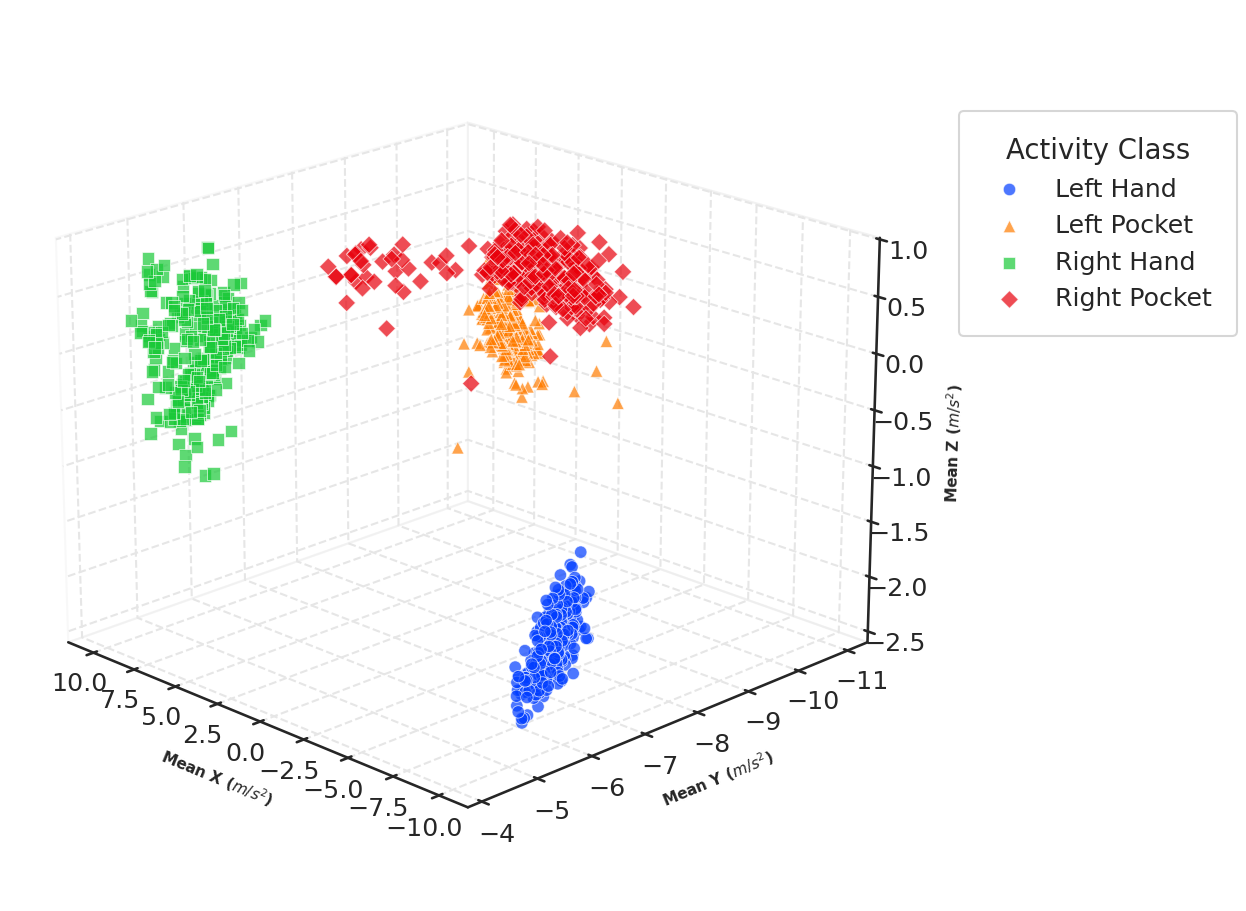

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Aesthetics (Consistency with PCA plot)
plt.style.use('seaborn-v0_8-muted')
unique_classes = df_clean['class'].unique()
pca_palette = sns.color_palette("bright", n_colors=len(unique_classes))
markers = ['o', '^', 's', 'D']

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 2. Iterate through classes
for i, label in enumerate(unique_classes):
    subset = df_clean[df_clean['class'] == label]
    ax.scatter(subset['mean_x'], subset['mean_y'], subset['mean_z'],
               color=pca_palette[i],
               label=label.replace('_', ' ').title(), # Clean label names
               s=80,             # Increased size
               alpha=0.7,        # Slight transparency for overlapping clusters
               edgecolors='white',
               linewidth=0.6,
               marker=markers[i])

# 3. Beautifying the 3D Environment
# Remove solid gray background panes for a modern "airy" look
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Subtle gridlines
ax.xaxis._axinfo["grid"]['linestyle'] = "--"
ax.yaxis._axinfo["grid"]['linestyle'] = "--"
ax.zaxis._axinfo["grid"]['linestyle'] = "--"
ax.xaxis._axinfo["grid"]['alpha'] = 0.3

# 4. Labels and Title (Using Semibold)
ax.set_xlabel('Mean X ($m/s^2$)', fontsize=11, labelpad=12, weight='semibold')
ax.set_ylabel('Mean Y ($m/s^2$)', fontsize=11, labelpad=12, weight='semibold')
ax.set_zlabel('Mean Z ($m/s^2$)', fontsize=11, labelpad=12, weight='semibold')


# 5. Legend and View Orientation
ax.view_init(elev=20, azim=135)
ax.legend(title="Activity Class",
          bbox_to_anchor=(1.05, 0.9), # Move legend outside to the right
          loc='upper left',
          frameon=True,
          shadow=False,
          borderpad=1)

plt.tight_layout()
plt.savefig('3D_gravity.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

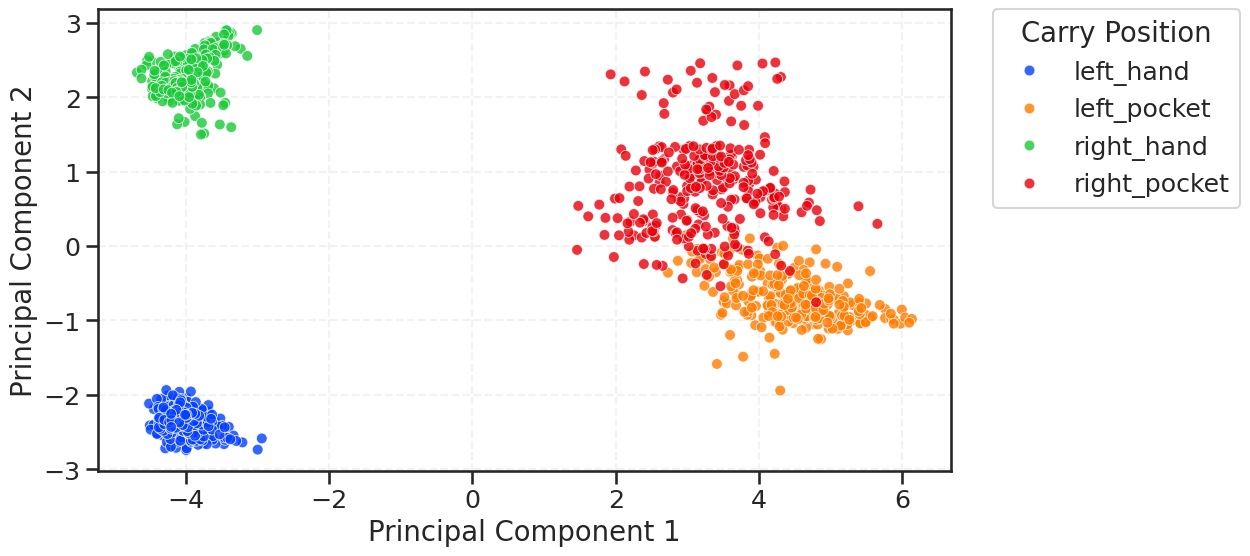

In [16]:
# PCA Visualization
X_pca = df_clean.drop('class', axis=1)
y_pca = df_clean['class']

# Standardize and transform
pca = PCA(n_components=2)
X_pca_trans = pca.fit_transform(StandardScaler().fit_transform(X_pca))

plt.figure(figsize=(11, 6)) # Slightly wider to accommodate the legend
sns.scatterplot(
    x=X_pca_trans[:,0],
    y=X_pca_trans[:,1],
    hue=y_pca,
    palette='bright',
    s=60,
    alpha=0.8
)

# --- FIX: Move legend outside to the top right ---
plt.legend(title='Carry Position', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('pca.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# export arff
def save_arff(df, filename):
    with open(filename, 'w') as f:
        f.write(f'@RELATION {filename}\n\n')
        for col in df.drop('class', axis=1).columns: f.write(f'@ATTRIBUTE {col} NUMERIC\n')
        f.write(f'@ATTRIBUTE class {{{",".join(df["class"].unique())}}}\n\n@DATA\n')
        for i in range(len(df)):
            line = ",".join([str(v) for v in df.drop('class', axis=1).iloc[i]]) + f",{df['class'].iloc[i]}\n"
            f.write(line)
    print(f" -> Saved: {filename}")

save_arff(df_clean, 'motion_tracking.arff')

 -> Saved: motion_tracking.arff


In [18]:
# model tuning (grid search)
classifiers = {
    "kNN": (KNeighborsClassifier(), {'n_neighbors': [3, 5]}),
    "Naive Bayes": (GaussianNB(), {'var_smoothing': [1e-9]}),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), {'max_depth': [None, 10]}),
    "MLP": (MLPClassifier(max_iter=800, random_state=42), {'hidden_layer_sizes': [(100,)]})
}

X_final = df_clean.drop('class', axis=1)
y_final = df_clean['class']
X_sc = StandardScaler().fit_transform(X_final)

best_model = None
best_score = 0
best_name = ""

for name, (model, params) in classifiers.items():
    grid = GridSearchCV(model, params, cv=StratifiedKFold(10), scoring='accuracy', n_jobs=-1)
    grid.fit(X_sc, y_final)
    print(f"{name}: {grid.best_score_*100:.2f}% (Params: {grid.best_params_})")
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_name = name

kNN: 99.92% (Params: {'n_neighbors': 3})
Naive Bayes: 99.83% (Params: {'var_smoothing': 1e-09})
Decision Tree: 99.66% (Params: {'max_depth': None})
MLP: 99.92% (Params: {'hidden_layer_sizes': (100,)})


We plot Learning Curves to diagnose bias vs. variance. Convergence of Training and CV scores at a high value indicates a robust model.

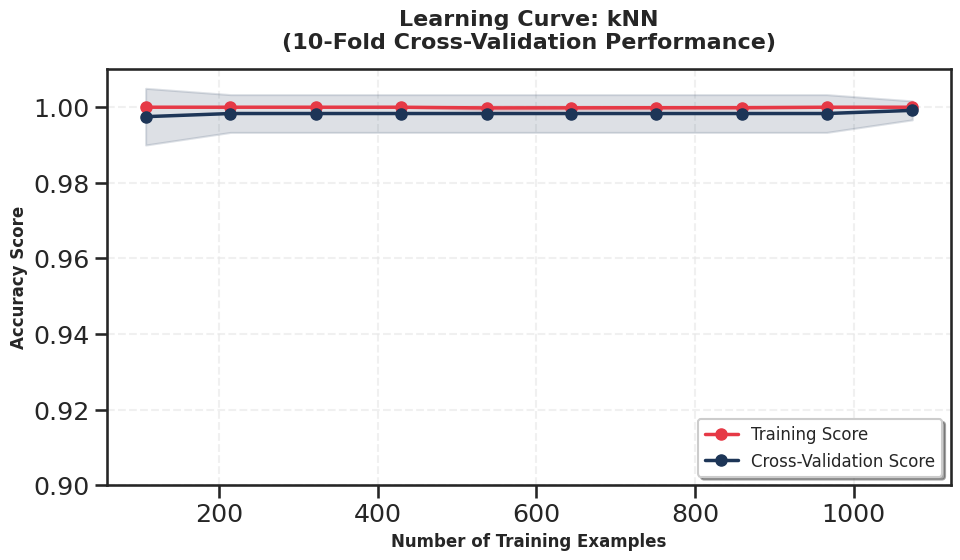

In [19]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# --- 1. COMPUTE LEARNING CURVE ---
# We use stratified 10-fold CV as per assignment requirements
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_sc, y_final,
    cv=10,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# Calculate mean and std dev
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# --- 2. PLOTTING ---
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-muted') # Ensures a clean academic look

# Plot Training Score (Red)
plt.plot(train_sizes, train_scores_mean, 'o-', color="#E63946",
         label="Training Score", linewidth=2.5, markersize=8)
# Plot Cross-Validation Score (Blue)
plt.plot(train_sizes, test_scores_mean, 'o-', color="#1D3557",
         label="Cross-Validation Score", linewidth=2.5, markersize=8)

# Add Shading for Variance (Variance is key for the 10-fold CV summary!)
plt.fill_between(train_sizes,
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std,
                 alpha=0.15, color="#E63946")
plt.fill_between(train_sizes,
                 test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std,
                 alpha=0.15, color="#1D3557")

# Formatting
plt.title(f"Learning Curve: {best_name}\n(10-Fold Cross-Validation Performance)",
          fontsize=16, weight='bold', pad=15)
plt.xlabel("Number of Training Examples", fontsize=12, weight='bold')
plt.ylabel("Accuracy Score", fontsize=12, weight='bold')
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

# RECOMMENDATION: Adjust y-limit based on your high accuracy
# If accuracy is very high, 0.9 to 1.01 makes the convergence easier to see
plt.ylim(0.9, 1.01)

plt.tight_layout()
plt.savefig('learning_curve.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

We calculate One-vs-Rest ROC curves. A perfect classifier has curves that hug the top-left corner (AUC = 1.0). The "Random Guess" line represents a model with no predictive power (50% accuracy).


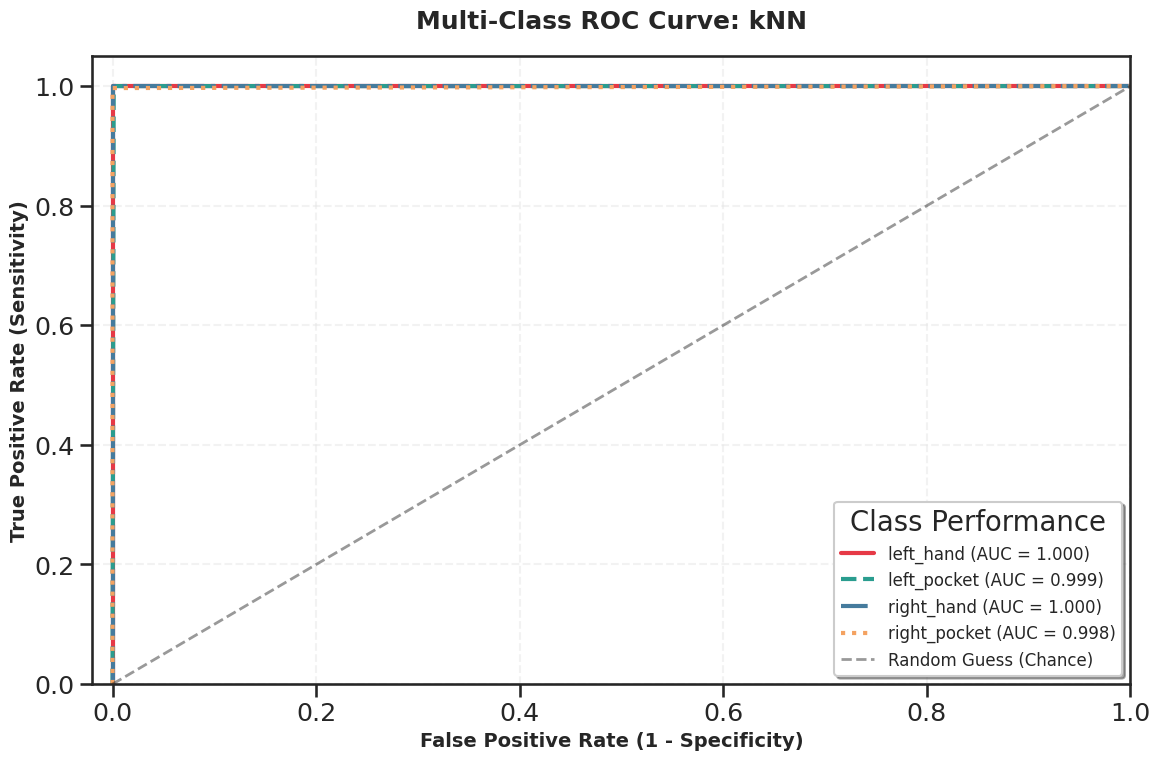

In [20]:
# One-vs-Rest format
y_bin = label_binarize(y_final, classes=best_model.classes_)
n_classes = y_bin.shape[1]

# get probabilities (needed for ROC)
if hasattr(best_model, "predict_proba"):
    y_score = cross_val_predict(best_model, X_sc, y_final, cv=10, method='predict_proba')

    # setup plot
    plt.figure(figsize=(12, 8))
    colors = ['#E63946', '#2A9D8F', '#457B9D', '#F4A261'] # Red, Green, Blue, Orange
    line_styles = ['-', '--', '-.', ':']

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        # Plot each class curve
        plt.plot(fpr, tpr,
                 color=colors[i],
                 linestyle=line_styles[i],
                 lw=3, # Thicker lines for visibility
                 label=f'{best_model.classes_[i]} (AUC = {roc_auc:.3f})')

    # Plot "Random Guess" Line (Diagonal)
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.4, label='Random Guess (Chance)')
    plt.title(f'Multi-Class ROC Curve: {best_name}', fontsize=18, weight='bold', pad=20)
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14, weight='bold')
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=14, weight='bold')
    plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True, title="Class Performance")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.05])
    plt.tight_layout()
    plt.savefig('roc_curve.eps', format='eps', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("Selected model does not support probability predictions needed for ROC.")

We visualize the performance of our best model. Diagonal values represent correct predictions off-diagonal values are errors.


/tmp/ipython-input-36054781.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


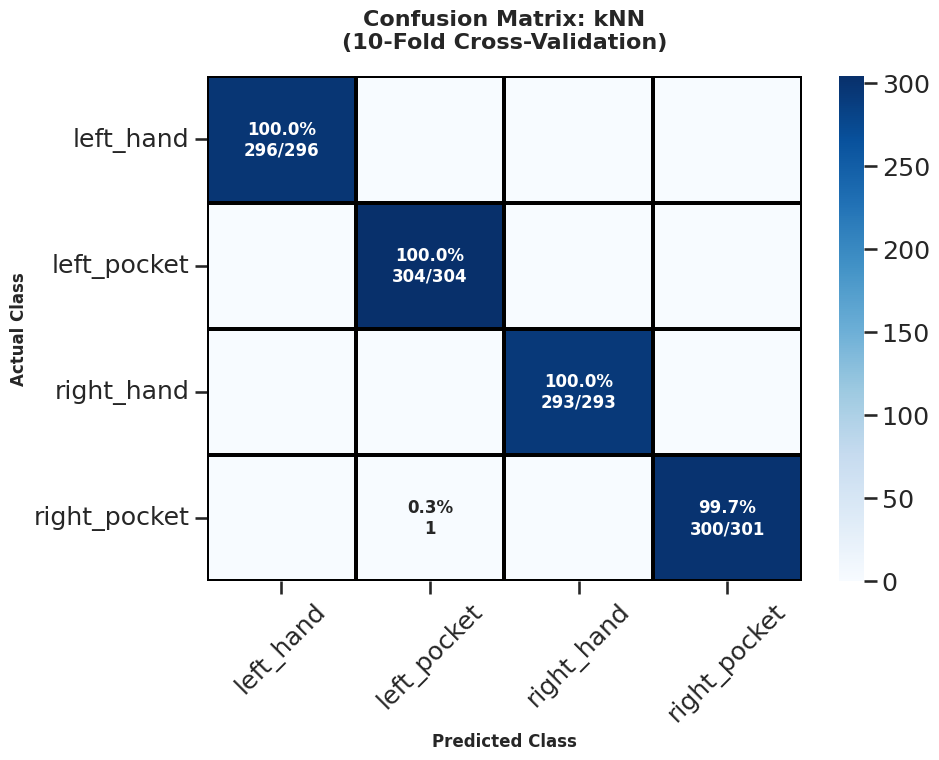

In [21]:
# generate predictions
y_pred = cross_val_predict(best_model, X_sc, y_final, cv=10)
cm = confusion_matrix(y_final, y_pred, labels=best_model.classes_)

# calculate percentages for annotation
cm_sum = np.sum(cm, axis=1, keepdims=True)
cm_perc = cm / cm_sum.astype(float) * 100
annot = np.empty_like(cm).astype(str)
nrows, ncols = cm.shape
for i in range(nrows):
    for j in range(ncols):
        c = cm[i, j]
        p = cm_perc[i, j]
        if i == j:
            s = cm_sum[i]
            annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
        elif c == 0:
            annot[i, j] = ''
        else:
            annot[i, j] = '%.1f%%\n%d' % (p, c)

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', linewidths=1.5, linecolor='black',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_,
            annot_kws={"size": 12, "weight": "bold"})

plt.title(f"Confusion Matrix: {best_name}\n(10-Fold Cross-Validation)", fontsize=16, weight='bold', pad=20)
plt.ylabel('Actual Class', fontsize=12, weight='bold')
plt.xlabel('Predicted Class', fontsize=12, weight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_knn.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

We use SHAP to explain *why* the model made predictions. This bar chart ranks features by their impact on the model's decision making. We use the Decision Tree (TreeExplainer) for speed and clarity.

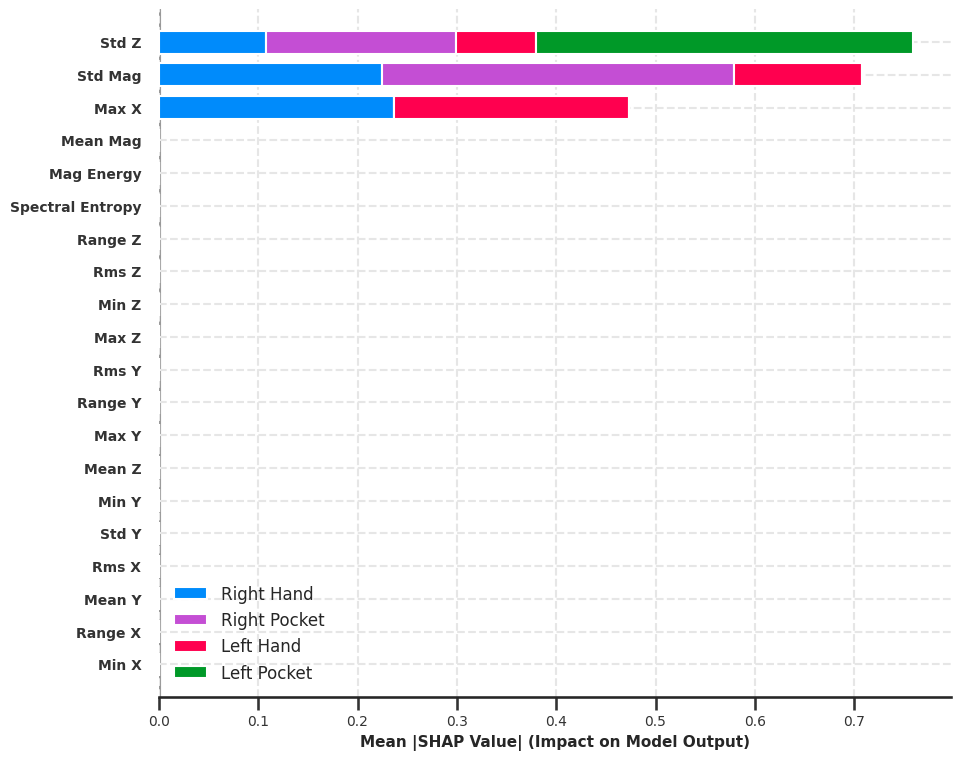

In [22]:
import matplotlib.pyplot as plt
import shap
import pandas as pd

# 1. Clean Feature Names for the Plot
# This changes 'min_y' to 'Min Y' for a professional look
X_display = X_final.copy()
X_display.columns = [col.replace('_', ' ').title() for col in X_display.columns]

# 2. Setup the Explainer and SHAP values
explainer_model = DecisionTreeClassifier(random_state=42).fit(X_display, y_final)
explainer = shap.TreeExplainer(explainer_model)
shap_values = explainer.shap_values(X_display)

# 3. Beautify and Create the Plot
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-muted')

# SHAP summary plot with class names
# Note: Ensure class_names matches your label encoder's order
class_names = [c.replace('_', ' ').title() for c in explainer_model.classes_]

shap.summary_plot(
    shap_values,
    X_display,
    plot_type="bar",
    class_names=class_names,
    show=False,
    plot_size=None # We control size with plt.figure
)

# 4. Final Styling (Semibold and Labels)

plt.xlabel('Mean |SHAP Value| (Impact on Model Output)',
           fontsize=11, weight='semibold')

# Set tick labels to semibold for consistency
plt.gca().tick_params(axis='both', which='major', labelsize=10)
for label in plt.gca().get_yticklabels():
    label.set_weight('semibold')

plt.tight_layout()
plt.savefig('shap_plot.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

We isolate the specific rows where the model failed.

In [23]:
mistakes = X_final[y_final != y_pred]
if len(mistakes) > 0:
    print(f"Found {len(mistakes)} errors. Showing first 5:")
    print(mistakes.head())
else:
    print("No misclassifications found.")

Found 1 errors. Showing first 5:
       mean_x     std_x     min_x      max_x    range_x     rms_x    mean_y  \
909  2.214732  5.789426 -7.508916  18.295759  25.804675  6.184918 -8.375727   

        std_y      min_y     max_y  ...    mean_z     std_z      min_z  \
909  6.140231 -32.591393  1.888059  ... -0.500087  4.284853 -14.759547   

        max_z    range_z     rms_z   mean_mag   std_mag  mag_energy  \
909  9.081764  23.841312  4.303176  11.314782  6.179934  166.022999   

     spectral_entropy  
909          2.604027  

[1 rows x 22 columns]


In [24]:
# summary
print("\n" + "="*40)
print(f"FINAL REPORT ")
print("="*40)
print(f"1. Best Classifier:    {best_name}")
print(f"2. Best CV Accuracy:   {best_score*100:.2f}%")
print(f"3. Outliers Removed:   {len(df_all) - len(df_clean)}")
print(f"4. Total Features:     {X_final.shape[1]}")
print(f"5. Saved Model:        {filename}")
print("="*40)


FINAL REPORT 
1. Best Classifier:    kNN
2. Best CV Accuracy:   99.92%
3. Outliers Removed:   25
4. Total Features:     22
5. Saved Model:        right_pocket.csv
